# EPO Experiment Results

In [17]:
import json
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_PATH = "/users/sgdbareh/scratch/EPO_NEW/EPO-Project/Results/results_main.json"
SW_PATH      = "/users/sgdbareh/scratch/EPO_NEW/EPO-Project/Results/results_sliding_window.json"

with open(RESULTS_PATH) as f:
    results_main = json.load(f)
with open(SW_PATH) as f:
    sw_results = json.load(f)

# Clean up algo names
ALGO_NAMES = {
    "RandomForestClassifier": "RandomForest",
    "XGBClassifier": "XGBoost",
}
def clean_algo(name):
    return ALGO_NAMES.get(name, name)

print(f"results_main.json:           {len(results_main)} records")
print(f"results_sliding_window.json: {len(sw_results)} records")


results_main.json:           144 records
results_sliding_window.json: 484 records


## ML RESULTS

### 1. ML Validation Results (CV best score)

In [18]:
# ML Validation CV F1 — rows=algo, cols=feature, grouped by Case + Exp
rows = []
for r in results_main:
    rows.append({
        "Exp":       r["experiment"],
        "Case":      r["case_mode"],
        "Algorithm": clean_algo(r["algo"]),
        "Features":  r["input_representation"],
        "Val F1":    round(r["best_score_cv"], 4),
    })

df_val = pd.DataFrame(rows)

for (case, exp), grp in df_val.groupby(["Case", "Exp"]):
    pivot = (grp.pivot_table(index="Algorithm", columns="Features", values="Val F1", aggfunc="first")
               .rename_axis(None, axis=1)
               .reset_index())
    print(f"\nValidation CV F1  |  Case: {case.upper()}  |  Exp {exp}")
    display(pivot)



Validation CV F1  |  Case: BOTH  |  Exp 1


,Algorithm,Doc2Vec,Law2Vec,N-Grams,Patent2Vec,TF-IDF,Word2Vec
0,LinearSVC,0.6474,0.6483,0.7604,0.6618,0.7510,0.6615
1,LogisticRegression,0.6480,0.6471,0.7536,0.6622,0.7508,0.6609
2,RandomForest,0.6945,0.6418,0.7689,0.6465,0.7755,0.6396
3,XGBoost,0.7152,0.6776,0.8222,0.6963,0.8163,0.6918



Validation CV F1  |  Case: BOTH  |  Exp 2


,Algorithm,Doc2Vec,Law2Vec,N-Grams,Patent2Vec,TF-IDF,Word2Vec
0,LinearSVC,0.6391,0.6341,0.7618,0.6644,0.7542,0.6539
1,LogisticRegression,0.6404,0.6358,0.7543,0.6649,0.7531,0.6559
2,RandomForest,0.5905,0.5510,0.7446,0.5751,0.7587,0.5557
3,XGBoost,0.6772,0.6405,0.8065,0.6701,0.8062,0.6489



Validation CV F1  |  Case: OP  |  Exp 1


...

,Algorithm,Doc2Vec,Law2Vec,N-Grams,Patent2Vec,TF-IDF,Word2Vec
0,LinearSVC,0.6030,0.6049,0.7002,0.6124,0.6784,0.6018
1,LogisticRegression,0.6041,0.6046,0.6933,0.6153,0.6827,0.6068
2,RandomForest,0.6313,0.6177,0.7071,0.6121,0.7180,0.6125
3,XGBoost,0.6754,0.6402,0.7696,0.6662,0.7591,0.6503



Validation CV F1  |  Case: PF  |  Exp 1


,Algorithm,Doc2Vec,Law2Vec,N-Grams,Patent2Vec,TF-IDF,Word2Vec
0,LinearSVC,0.7101,0.6954,0.8480,0.7231,0.8414,0.6978
1,LogisticRegression,0.7096,0.6958,0.8462,0.7260,0.8436,0.6995
2,RandomForest,0.6877,0.6631,0.8343,0.6685,0.8362,0.6609
3,XGBoost,0.7195,0.6907,0.8599,0.7139,0.8559,0.6967



Validation CV F1  |  Case: PF  |  Exp 2


,Algorithm,Doc2Vec,Law2Vec,N-Grams,Patent2Vec,TF-IDF,Word2Vec
0,LinearSVC,0.6967,0.6784,0.8419,0.7163,0.8419,0.7059
1,LogisticRegression,0.7039,0.6807,0.8400,0.7238,0.8434,0.7060
2,RandomForest,0.6347,0.5757,0.8223,0.6080,0.8284,0.5844
3,XGBoost,0.7032,0.6580,0.8472,0.6898,0.8449,0.6605


### 2. ML Full Test Results

In [19]:
# ML Full Test — all metrics in one table, cols = "Feature | Metric", grouped by Case + Exp
rows = []
for r in sw_results:
    if r.get("mode") != "full_test_ml":
        continue
    m = r.get("test_metrics", {})
    rows.append({
        "Exp":       r["experiment"],
        "Case":      r["case_mode"],
        "Algorithm": clean_algo(r["algo"]),
        "Features":  r["input_representation"],
        "F1":        round(m.get("f1",       float("nan")), 4),
        "Accuracy":  round(m.get("accuracy", float("nan")), 4),
        "AUC":       round(m.get("auc",      float("nan")), 4),
        "MCC":       round(m.get("mcc",      float("nan")), 4),
    })

df_test = pd.DataFrame(rows)
METRICS = ["F1", "Accuracy", "AUC", "MCC"]

for (case, exp), grp in df_test.groupby(["Case", "Exp"]):
    pivot = grp.pivot_table(index="Algorithm", columns="Features", values=METRICS, aggfunc="first")
    # Flatten to "Feature | Metric" columns
    pivot = pivot.swaplevel(axis=1).sort_index(axis=1)
    pivot.columns = [f"{feat} | {metric}" for feat, metric in pivot.columns]
    pivot = pivot.reset_index()
    print(f"\nFull Test Results  |  Case: {case.upper()}  |  Exp {exp}")
    display(pivot)



Full Test Results  |  Case: BOTH  |  Exp 1


,Algorithm,Doc2Vec | AUC,Doc2Vec | Accuracy,Doc2Vec | F1,Doc2Vec | MCC,Law2Vec | AUC,Law2Vec | Accuracy,Law2Vec | F1,Law2Vec | MCC,N-Grams | AUC,N-Grams | Accuracy,N-Grams | F1,N-Grams | MCC,Patent2Vec | AUC,Patent2Vec | Accuracy,Patent2Vec | F1,Patent2Vec | MCC,TF-IDF | AUC,TF-IDF | Accuracy,TF-IDF | F1,TF-IDF | MCC,Word2Vec | AUC,Word2Vec | Accuracy,Word2Vec | F1,Word2Vec | MCC
0,LinearSVC,0.6796,0.6301,0.6022,0.2597,0.7095,0.6560,0.6134,0.3037,0.8404,0.7654,0.7383,0.5262,0.7244,0.6664,0.6209,0.3230,0.8345,0.7546,0.7230,0.5028,0.7181,0.6592,0.6162,0.3098
1,LogisticRegression,0.6805,0.6303,0.6032,0.2606,0.7078,0.6534,0.6106,0.2985,0.8341,0.7629,0.7338,0.5202,0.7236,0.6655,0.6201,0.3214,0.8377,0.7582,0.7277,0.5104,0.7176,0.6630,0.6214,0.3179
2,RandomForest,0.7593,0.6918,0.6417,0.3719,0.7205,0.6636,0.5940,0.3105,0.8663,0.7818,0.7405,0.5546,0.7517,0.6838,0.6195,0.3523,0.8717,0.7888,0.7473,0.5690,0.7188,0.6611,0.5646,0.3016
3,XGBoost,0.7836,0.7073,0.6750,0.4094,0.7486,0.6783,0.6394,0.3492,0.9029,0.8284,0.8067,0.6526,0.7778,0.7035,0.6668,0.3999,0.9020,0.8216,0.7986,0.6386,0.7600,0.6920,0.6564,0.3778



Full Test Results  |  Case: BOTH  |  Exp 2


,Algorithm,Doc2Vec | AUC,Doc2Vec | Accuracy,Doc2Vec | F1,Doc2Vec | MCC,Law2Vec | AUC,Law2Vec | Accuracy,Law2Vec | F1,Law2Vec | MCC,N-Grams | AUC,N-Grams | Accuracy,N-Grams | F1,N-Grams | MCC,Patent2Vec | AUC,Patent2Vec | Accuracy,Patent2Vec | F1,Patent2Vec | MCC,TF-IDF | AUC,TF-IDF | Accuracy,TF-IDF | F1,TF-IDF | MCC,Word2Vec | AUC,Word2Vec | Accuracy,Word2Vec | F1,Word2Vec | MCC
0,LinearSVC,0.6821,0.6388,0.6367,0.2802,0.6985,0.6485,0.6125,0.2932,0.8013,0.7281,0.7083,0.4540,0.7096,0.6558,0.6328,0.3091,0.7938,0.7248,0.7072,0.4478,0.7020,0.6524,0.6182,0.3012
1,LogisticRegression,0.6801,0.6360,0.6375,0.2758,0.6967,0.6462,0.6110,0.2885,0.7823,0.7163,0.6933,0.4301,0.7087,0.6526,0.6307,0.3028,0.8002,0.7222,0.7072,0.4429,0.7012,0.6528,0.6200,0.3020
2,RandomForest,0.7729,0.7009,0.6589,0.4000,0.7279,0.6680,0.6075,0.3345,0.8323,0.7579,0.7300,0.5148,0.7374,0.6733,0.6260,0.3439,0.8537,0.7749,0.7366,0.5545,0.7381,0.6742,0.6161,0.3473
3,XGBoost,0.7872,0.7096,0.6806,0.4167,0.7522,0.6869,0.6537,0.3709,0.8924,0.8114,0.7980,0.6215,0.7704,0.7012,0.6725,0.3997,0.8910,0.8101,0.7932,0.6192,0.7614,0.6943,0.6643,0.3857



Full Test Results  |  Case: OP  |  Exp 1


...

,Algorithm,Doc2Vec | AUC,Doc2Vec | Accuracy,Doc2Vec | F1,Doc2Vec | MCC,Law2Vec | AUC,Law2Vec | Accuracy,Law2Vec | F1,Law2Vec | MCC,N-Grams | AUC,N-Grams | Accuracy,N-Grams | F1,N-Grams | MCC,Patent2Vec | AUC,Patent2Vec | Accuracy,Patent2Vec | F1,Patent2Vec | MCC,TF-IDF | AUC,TF-IDF | Accuracy,TF-IDF | F1,TF-IDF | MCC,Word2Vec | AUC,Word2Vec | Accuracy,Word2Vec | F1,Word2Vec | MCC
0,LinearSVC,0.6785,0.6459,0.5505,0.2587,0.6801,0.6485,0.5019,0.2367,0.7407,0.6921,0.6179,0.3616,0.6913,0.6544,0.5412,0.2645,0.7306,0.6814,0.6129,0.3458,0.6762,0.6477,0.5336,0.2510
1,LogisticRegression,0.6746,0.6501,0.5613,0.2711,0.6782,0.6437,0.4951,0.2262,0.7385,0.6852,0.6119,0.3491,0.6889,0.6522,0.5381,0.2598,0.7464,0.6958,0.6203,0.3677,0.6765,0.6491,0.5342,0.2532
2,RandomForest,0.7638,0.7128,0.6045,0.3824,0.7217,0.6687,0.5233,0.2784,0.8011,0.7475,0.6629,0.4621,0.7216,0.6756,0.5347,0.2943,0.8249,0.7640,0.6682,0.4917,0.7279,0.6703,0.5252,0.2818
3,XGBoost,0.7841,0.7162,0.6153,0.3925,0.7436,0.6836,0.5640,0.3190,0.8697,0.8004,0.7447,0.5810,0.7385,0.6889,0.5672,0.3288,0.8543,0.7874,0.7300,0.5550,0.7607,0.7008,0.5882,0.3566



Full Test Results  |  Case: PF  |  Exp 1


,Algorithm,Doc2Vec | AUC,Doc2Vec | Accuracy,Doc2Vec | F1,Doc2Vec | MCC,Law2Vec | AUC,Law2Vec | Accuracy,Law2Vec | F1,Law2Vec | MCC,N-Grams | AUC,N-Grams | Accuracy,N-Grams | F1,N-Grams | MCC,Patent2Vec | AUC,Patent2Vec | Accuracy,Patent2Vec | F1,Patent2Vec | MCC,TF-IDF | AUC,TF-IDF | Accuracy,TF-IDF | F1,TF-IDF | MCC,Word2Vec | AUC,Word2Vec | Accuracy,Word2Vec | F1,Word2Vec | MCC
0,LinearSVC,0.7818,0.7228,0.7936,0.4059,0.7702,0.6977,0.7747,0.3483,0.9271,0.8531,0.8953,0.6641,0.8209,0.7391,0.8081,0.4280,0.9279,0.8503,0.8927,0.6627,0.7861,0.7083,0.7813,0.3806
1,LogisticRegression,0.7763,0.7200,0.7922,0.3945,0.7710,0.6988,0.7754,0.3511,0.9188,0.8414,0.8856,0.6480,0.8216,0.7398,0.8087,0.4290,0.9288,0.8545,0.8964,0.6666,0.7866,0.7097,0.7826,0.3825
2,RandomForest,0.7738,0.6906,0.7630,0.3679,0.7403,0.6517,0.7265,0.3118,0.9079,0.8312,0.8789,0.6174,0.7540,0.6602,0.7357,0.3185,0.9155,0.8354,0.8816,0.6302,0.7337,0.6425,0.7194,0.2900
3,XGBoost,0.7997,0.7218,0.7917,0.4098,0.7693,0.6899,0.7659,0.3470,0.9349,0.8527,0.8954,0.6596,0.8083,0.7214,0.7916,0.4080,0.9369,0.8634,0.9026,0.6891,0.7682,0.6832,0.7604,0.3339



Full Test Results  |  Case: PF  |  Exp 2


,Algorithm,Doc2Vec | AUC,Doc2Vec | Accuracy,Doc2Vec | F1,Doc2Vec | MCC,Law2Vec | AUC,Law2Vec | Accuracy,Law2Vec | F1,Law2Vec | MCC,N-Grams | AUC,N-Grams | Accuracy,N-Grams | F1,N-Grams | MCC,Patent2Vec | AUC,Patent2Vec | Accuracy,Patent2Vec | F1,Patent2Vec | MCC,TF-IDF | AUC,TF-IDF | Accuracy,TF-IDF | F1,TF-IDF | MCC,Word2Vec | AUC,Word2Vec | Accuracy,Word2Vec | F1,Word2Vec | MCC
0,LinearSVC,0.7839,0.7306,0.7960,0.3994,0.7610,0.7087,0.7767,0.3579,0.9164,0.8565,0.8893,0.6861,0.7939,0.7410,0.8053,0.4191,0.9240,0.8521,0.8854,0.6780,0.7428,0.6851,0.7503,0.3279
1,LogisticRegression,0.7758,0.7333,0.7982,0.4053,0.7606,0.7081,0.7758,0.3579,0.9127,0.8417,0.8762,0.6589,0.7951,0.7333,0.7983,0.4048,0.9259,0.8571,0.8895,0.6877,0.7418,0.6884,0.7534,0.3338
2,RandomForest,0.7626,0.7174,0.7859,0.3705,0.7323,0.6873,0.7559,0.3225,0.9070,0.8341,0.8717,0.6377,0.7428,0.6955,0.7695,0.3212,0.9178,0.8434,0.8790,0.6576,0.7008,0.6670,0.7379,0.2840
3,XGBoost,0.7895,0.7448,0.8034,0.4402,0.7497,0.6966,0.7637,0.3413,0.9316,0.8587,0.8890,0.6977,0.7732,0.7169,0.7865,0.3668,0.9317,0.8549,0.8869,0.6861,0.7396,0.6917,0.7633,0.3212


### 3. ML Sliding Window Results (Exp 2, years 2021–2024)

In [20]:
# ML Sliding Window F1 — cols = "Feature Year", grouped by Case
rows = []
for r in sw_results:
    if r.get("mode") != "sliding_window_ml":
        continue
    rows.append({
        "Case":      r["case_mode"],
        "Algorithm": clean_algo(r["algo"]),
        "Features":  r["input_representation"],
        "Year":      r["test_year"],
        "F1":        round(r["test_metrics"].get("f1", float("nan")), 4),
    })

df_sw = pd.DataFrame(rows)

for case, cgrp in df_sw.groupby("Case"):
    pivot = cgrp.pivot_table(index="Algorithm", columns=["Features", "Year"], values="F1", aggfunc="first")
    pivot.columns = [f"{feat} {yr}" for feat, yr in pivot.columns]
    pivot = pivot.rename_axis(None, axis=1).reset_index()
    print(f"\nSliding Window F1  |  Case: {case.upper()}")
    display(pivot)



Sliding Window F1  |  Case: BOTH


,Algorithm,Doc2Vec 2021,Doc2Vec 2022,Doc2Vec 2023,Doc2Vec 2024,Law2Vec 2021,Law2Vec 2022,Law2Vec 2023,Law2Vec 2024,N-Grams 2021,N-Grams 2022,N-Grams 2023,N-Grams 2024,Patent2Vec 2021,Patent2Vec 2022,Patent2Vec 2023,Patent2Vec 2024,TF-IDF 2021,TF-IDF 2022,TF-IDF 2023,TF-IDF 2024,Word2Vec 2021,Word2Vec 2022,Word2Vec 2023,Word2Vec 2024
0,LinearSVC,0.4322,0.4690,0.4887,0.4424,0.4264,0.4250,0.4495,0.4165,0.5655,0.5794,0.6283,0.6014,0.4463,0.4912,0.5080,0.4346,0.5773,0.5639,0.6273,0.5806,0.4448,0.4694,0.4810,0.4432
1,LogisticRegression,0.4391,0.4631,0.5026,0.4461,0.4367,0.4398,0.4444,0.4211,0.5877,0.5614,0.6240,0.5919,0.4502,0.5070,0.5142,0.4259,0.5576,0.5837,0.6039,0.5935,0.4503,0.4712,0.4757,0.4436
2,RandomForest,0.4275,0.5019,0.4575,0.4279,0.4307,0.4346,0.4091,0.3991,0.5217,0.5747,0.5271,0.5744,0.4038,0.4525,0.4168,0.4035,0.5350,0.5747,0.5282,0.5649,0.3735,0.4239,0.3966,0.3779
3,XGBoost,0.5499,0.5535,0.5689,0.5423,0.4966,0.4910,0.5417,0.5075,0.7416,0.7411,0.7330,0.7479,0.5532,0.5383,0.5493,0.5379,0.7092,0.7219,0.7057,0.7372,0.4944,0.5167,0.5413,0.5558



Sliding Window F1  |  Case: OP


,Algorithm,Doc2Vec 2021,Doc2Vec 2022,Doc2Vec 2023,Doc2Vec 2024,Law2Vec 2021,Law2Vec 2022,Law2Vec 2023,Law2Vec 2024,N-Grams 2021,N-Grams 2022,N-Grams 2023,N-Grams 2024,Patent2Vec 2021,Patent2Vec 2022,Patent2Vec 2023,Patent2Vec 2024,TF-IDF 2021,TF-IDF 2022,TF-IDF 2023,TF-IDF 2024,Word2Vec 2021,Word2Vec 2022,Word2Vec 2023,Word2Vec 2024
0,LinearSVC,0.4426,0.4704,0.5034,0.4304,0.4264,0.4250,0.4495,0.4165,0.5484,0.5864,0.6319,0.6351,0.4463,0.4912,0.5080,0.4346,0.5379,0.5898,0.6240,0.6037,0.4448,0.4694,0.4838,0.4432
1,LogisticRegression,0.4234,0.4570,0.4745,0.4299,0.4367,0.4302,0.4444,0.4250,0.5877,0.5614,0.6240,0.5919,0.4502,0.5070,0.5142,0.4259,0.5576,0.5837,0.6039,0.5935,0.4503,0.4712,0.4757,0.4436
2,RandomForest,0.3992,0.4764,0.4217,0.4518,0.4098,0.4431,0.4350,0.4044,0.5072,0.5458,0.5020,0.5342,0.3837,0.4350,0.4208,0.4158,0.5350,0.5747,0.5282,0.5649,0.2595,0.2816,0.2754,0.2895
3,XGBoost,0.5481,0.5556,0.5571,0.5192,0.4613,0.5009,0.5244,0.4680,0.7416,0.7411,0.7330,0.7479,0.4837,0.4636,0.4848,0.4793,0.7130,0.7363,0.7243,0.7553,0.4690,0.5381,0.5412,0.5434



Sliding Window F1  |  Case: PF


,Algorithm,Doc2Vec 2021,Doc2Vec 2022,Doc2Vec 2023,Doc2Vec 2024,Law2Vec 2021,Law2Vec 2022,Law2Vec 2023,Law2Vec 2024,N-Grams 2021,N-Grams 2022,N-Grams 2023,N-Grams 2024,Patent2Vec 2021,Patent2Vec 2022,Patent2Vec 2023,Patent2Vec 2024,TF-IDF 2021,TF-IDF 2022,TF-IDF 2023,TF-IDF 2024,Word2Vec 2021,Word2Vec 2022,Word2Vec 2023,Word2Vec 2024
0,LinearSVC,0.8105,0.8175,0.8168,0.8579,0.8122,0.7881,0.7845,0.8495,0.8935,0.8872,0.8993,0.9205,0.8058,0.7821,0.8368,0.8672,0.8976,0.8755,0.9117,0.9428,0.8068,0.7721,0.7920,0.8435
1,LogisticRegression,0.8211,0.8067,0.8299,0.8624,0.8029,0.7815,0.7788,0.8464,0.8724,0.8634,0.9124,0.9167,0.8100,0.7747,0.8354,0.8672,0.8918,0.8820,0.9081,0.9454,0.8030,0.7721,0.7877,0.8488
2,RandomForest,0.8062,0.7835,0.7986,0.8483,0.7965,0.7621,0.8041,0.8490,0.8966,0.8627,0.9019,0.9215,0.7986,0.7559,0.8179,0.8821,0.8978,0.8791,0.9164,0.9340,0.7726,0.7743,0.8007,0.8549
3,XGBoost,0.8167,0.8037,0.8250,0.8639,0.7911,0.7721,0.8118,0.8365,0.8983,0.9031,0.9267,0.9511,0.8211,0.7753,0.8331,0.8777,0.9060,0.8829,0.9101,0.9370,0.8029,0.7610,0.8103,0.8460


## Best Configuration per Algorithm (Full Test)

In [21]:
# Best result per algorithm — highest F1 across all cases, experiments and features
best_rows = (df_test
    .sort_values("F1", ascending=False)
    .groupby("Algorithm", as_index=False)
    .first()
    [["Algorithm", "Features", "Case", "Exp", "F1", "Accuracy", "AUC", "MCC"]]
    .sort_values("F1", ascending=False)
    .reset_index(drop=True))

print("Best Full-Test Result per Algorithm")
display(best_rows)


Best Full-Test Result per Algorithm


,Algorithm,Features,Case,Exp,F1,Accuracy,AUC,MCC
0,XGBoost,TF-IDF,pf,1,0.9026,0.8634,0.9369,0.6891
1,LogisticRegression,TF-IDF,pf,1,0.8964,0.8545,0.9288,0.6666
2,LinearSVC,N-Grams,pf,1,0.8953,0.8531,0.9271,0.6641
3,RandomForest,TF-IDF,pf,1,0.8816,0.8354,0.9155,0.6302


## Visualisations

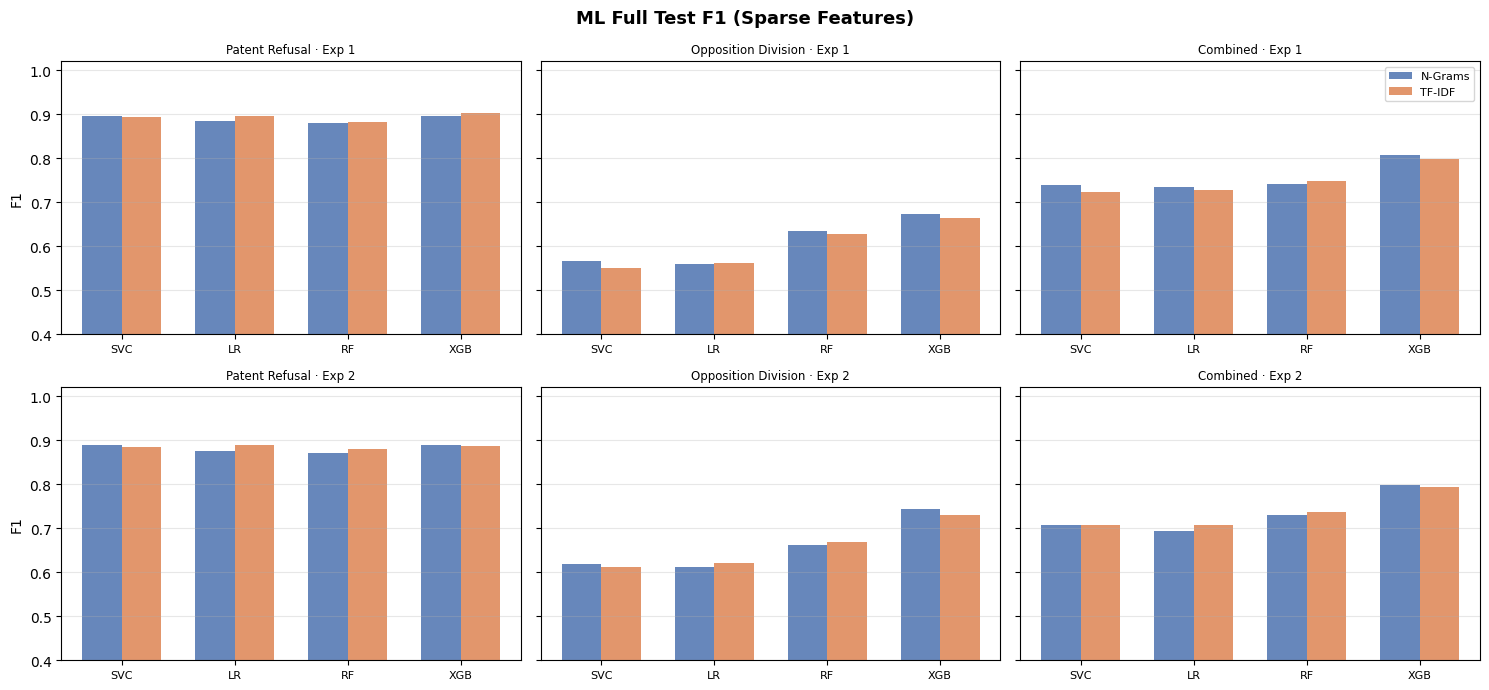

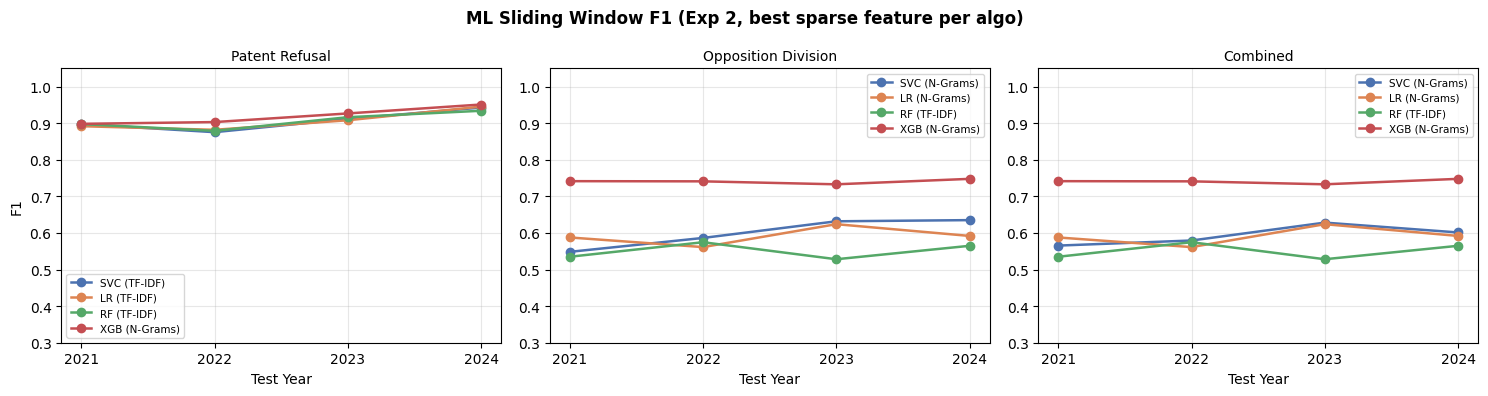

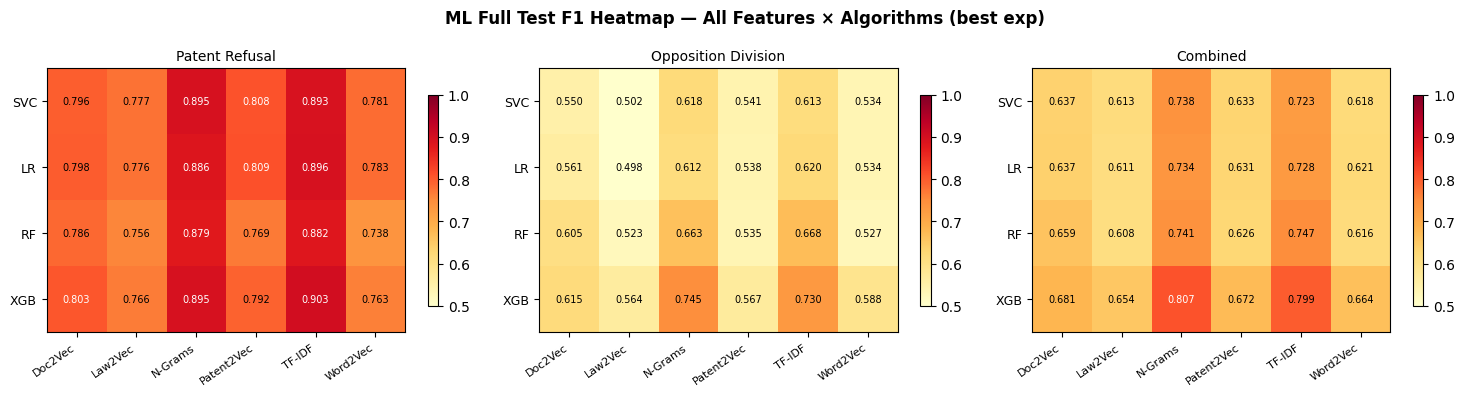

In [22]:
import matplotlib.pyplot as plt
import numpy as np

CASE_ORDER  = ["pf", "op", "both"]
CASE_LABELS = {"pf": "Patent Refusal", "op": "Opposition Division", "both": "Combined"}
ALGOS       = ["LinearSVC", "LogisticRegression", "RandomForest", "XGBoost"]
ALGO_SHORT  = {"LinearSVC": "SVC", "LogisticRegression": "LR", "RandomForest": "RF", "XGBoost": "XGB"}
SPARSE_FEATS = ["N-Grams", "TF-IDF"]
colors = {"N-Grams": "#4C72B0", "TF-IDF": "#DD8452"}
line_colors = {"LinearSVC": "#4C72B0", "LogisticRegression": "#DD8452",
               "RandomForest": "#55A868", "XGBoost": "#C44E52"}

# ── Plot 1: Grouped bar — sparse features, full test F1, faceted case × exp ──
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
fig.suptitle("ML Full Test F1 (Sparse Features)", fontsize=13, fontweight="bold")
x = np.arange(len(ALGOS))
w = 0.35
for col_i, case in enumerate(CASE_ORDER):
    for row_i, exp in enumerate(["1", "2"]):
        ax = axes[row_i][col_i]
        sub = df_test[(df_test["Case"] == case) & (df_test["Exp"] == exp)]
        for fi, feat in enumerate(SPARSE_FEATS):
            vals = [sub[(sub["Algorithm"] == a) & (sub["Features"] == feat)]["F1"].values
                    for a in ALGOS]
            vals = [v[0] if len(v) else np.nan for v in vals]
            ax.bar(x + (fi - 0.5) * w, vals, w, label=feat, color=colors[feat], alpha=0.85)
        ax.set_title(f"{CASE_LABELS[case]} · Exp {exp}", fontsize=8.5)
        ax.set_xticks(x)
        ax.set_xticklabels([ALGO_SHORT[a] for a in ALGOS], fontsize=8)
        ax.set_ylim(0.4, 1.02)
        ax.set_ylabel("F1" if col_i == 0 else "")
        ax.grid(axis="y", alpha=0.3)
        if row_i == 0 and col_i == 2:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 2: Sliding window F1 over time ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("ML Sliding Window F1 (Exp 2, best sparse feature per algo)", fontsize=12, fontweight="bold")
sw_sparse = df_sw[df_sw["Features"].isin(SPARSE_FEATS)]
for i, case in enumerate(CASE_ORDER):
    ax = axes[i]
    sub = sw_sparse[sw_sparse["Case"] == case]
    for algo in ALGOS:
        algo_sub = sub[sub["Algorithm"] == algo]
        if algo_sub.empty:
            continue
        best_feat = algo_sub.groupby("Features")["F1"].mean().idxmax()
        line = algo_sub[algo_sub["Features"] == best_feat].sort_values("Year")
        ax.plot(line["Year"], line["F1"], marker="o", linewidth=1.8,
                label=f"{ALGO_SHORT[algo]} ({best_feat})", color=line_colors[algo])
    ax.set_title(CASE_LABELS[case], fontsize=10)
    ax.set_xticks([2021, 2022, 2023, 2024])
    ax.set_xlabel("Test Year")
    ax.set_ylabel("F1" if i == 0 else "")
    ax.set_ylim(0.3, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

# ── Plot 3: Heatmap — all feature types × algo, best-exp F1 ──
all_feats = sorted(df_test["Features"].unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("ML Full Test F1 Heatmap — All Features × Algorithms (best exp)", fontsize=12, fontweight="bold")
for i, case in enumerate(CASE_ORDER):
    ax = axes[i]
    sub = df_test[df_test["Case"] == case]
    heat = (sub.groupby(["Algorithm", "Features"])["F1"].max()
              .unstack("Features")
              .reindex(index=ALGOS, columns=all_feats))
    im = ax.imshow(heat.values, vmin=0.5, vmax=1.0, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(all_feats)))
    ax.set_xticklabels(all_feats, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(ALGOS)))
    ax.set_yticklabels([ALGO_SHORT[a] for a in ALGOS], fontsize=9)
    ax.set_title(CASE_LABELS[case], fontsize=10)
    for r in range(len(ALGOS)):
        for c in range(len(all_feats)):
            v = heat.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=7,
                        color="black" if v < 0.8 else "white")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## DL RESULTS